In [156]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import jensenshannon
from torch.nn.utils.rnn import pack_padded_sequence
import torch
import torch.nn as nn
import random

# prepare the labels y

In [157]:
data = torch.load('fm-rna_embeddings.pt')
embeddings = data['embeddings']
fpts = data['labels']
ids = data['ids']

In [158]:
arr_fpts = np.array([row for row in fpts])

In [159]:
arr_fpts.shape

(2654, 1000)

In [160]:
np.min(arr_fpts)

0.0

In [161]:
np.max(arr_fpts)

297458098.413

In [162]:
np.where(arr_fpts == 0)

(array([ 251,  258,  274,  274,  274,  274,  274,  274,  274,  333,  349,
         349,  453,  459,  464,  465,  465,  465,  465,  478,  480,  480,
         482,  484,  484,  484,  484,  491,  491,  491,  491,  527, 1373,
        1441, 1490, 1490, 1490, 1497, 1510, 1510, 1510, 1514, 1514, 1531,
        1897, 2157, 2167, 2167, 2179, 2183, 2201, 2220, 2235, 2245, 2248,
        2253, 2253, 2255, 2256, 2256, 2257, 2267, 2282, 2282, 2282, 2295,
        2296, 2296, 2298, 2298, 2316, 2316, 2322, 2328, 2328, 2328, 2355,
        2355, 2361, 2361, 2361, 2381, 2381, 2390, 2446]),
 array([ 81, 180, 186, 211, 222, 408, 472, 555, 965, 153, 412, 864, 560,
         11, 389,  66, 250, 625, 641, 903, 420, 612, 230, 276, 306, 452,
        783,  40, 141, 432, 792, 643, 805, 460, 148, 175, 728, 730, 208,
        270, 368, 777, 928, 529, 320, 454, 468, 774, 626,  53, 920, 921,
        808, 525, 892, 135, 360, 589, 617, 702, 865, 711,  70, 601, 719,
        792, 226, 597, 553, 751,   8, 332, 531, 396, 552, 6

In [163]:
where_arr_fpts_nonzero = np.where(arr_fpts != 0)
arr_logfpts = np.log(arr_fpts[where_arr_fpts_nonzero])

In [164]:
np.min(arr_logfpts)

-6.907755278982137

In [165]:
np.max(arr_logfpts)

19.510783927359686

In [166]:
arr_logfpts.shape

(2653915,)

In [167]:
n_bins = 50

binedges_logfpt = np.linspace(np.min(arr_logfpts), np.max(arr_logfpts), n_bins+1)

In [168]:
arr_hist_logfpts = np.zeros((arr_fpts.shape[0], n_bins))
# for index, fpt in enumerate(arr_fpts[0:10]): # only do the first 10 for now
#     where_fpts_nonzero = np.where(fpts != 0)
#     logfpts = np.log(fpts[where_fpts_nonzero])
#     hist_logfpts, _ = np.histogram(logfpts, binedges_logfpt, density=True)
#     hist_logfpts /= np.sum(hist_logfpts) # normalize so that values add to 1; this does not reflect the probability density
#     arr_hist_logfpts[index] = hist_logfpts
i=0
for fpt in arr_fpts:
    
    fpt = np.array(fpt)
    where_nonzero = np.where(fpt != 0)          # fpt not fpts
    logfpts = np.log(fpt[where_nonzero])         # fpt not fpts
    hist_logfpts, _ = np.histogram(logfpts, binedges_logfpt, density=True)
    hist_logfpts /= np.sum(hist_logfpts)
    arr_hist_logfpts[i] = hist_logfpts
    i += 1


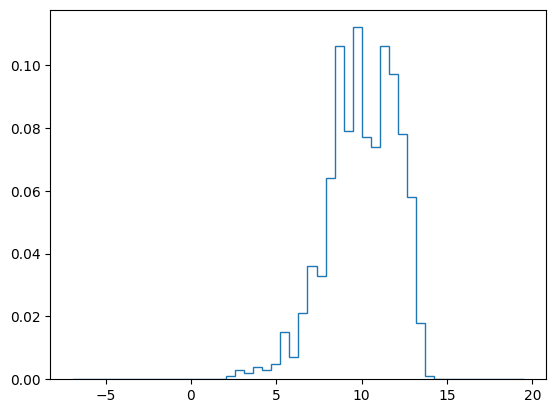

In [169]:
plt.stairs(arr_hist_logfpts[67], binedges_logfpt)

In [170]:
y = arr_hist_logfpts

In [171]:
np.sum(y, axis=1)

array([1., 1., 1., ..., 1., 1., 1.])

In [172]:
print(y.shape)

(2654, 50)


# prepare the features X

In [173]:
X = embeddings
X.shape

torch.Size([2654, 1920])

# train the model

In [174]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.15, random_state=42)


In [175]:
scaler = StandardScaler()

#center + rescale the data
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

In [176]:
from torch.utils.data import Dataset, DataLoader, Sampler

# 1. The Dataset simply holds your pre-sorted numpy data
class EmbeddingDataset(Dataset):
    def __init__(self, embeddings, targets):
        self.embeddings = embeddings       # List of arrays (sorted by length)
        self.targets = targets           # 1D NumPy array (sorted)        

    def __len__(self):
        return len(self.embeddings)

    def __getitem__(self, idx):
        return self.embeddings[idx], self.targets[idx]

In [177]:

class MLP(nn.Module):
    def __init__(self, hidden_size_1=256, hidden_size_2=64, embedding_size=1920, output_size=50, dropout_rate=0.3):
        super(MLP, self).__init__()
        # 3. The Fully Connected MLP Layers
        self.mlp = nn.Sequential(
            nn.Linear(embedding_size, hidden_size_1),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_size_1, hidden_size_2),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_size_2, output_size),
        )
    def forward(self, embeddings):
        output = self.mlp(embeddings)
        return output


In [178]:
X_train.shape

(1916, 1920)

In [179]:
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [195]:
set_seed(42) # does this work
# does this hidden size make sense?
# --- Model, Loss, Optimizer ---
model = MLP(hidden_size_1=128, hidden_size_2=64, embedding_size=X_train.shape[1], output_size=y_train.shape[1], dropout_rate=0.5)
# criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-2)
criterion = nn.KLDivLoss(reduction='batchmean')  # soft targets


# --- Build Datasets ---
train_dataset = EmbeddingDataset(X_train, y_train)
val_dataset   = EmbeddingDataset(X_val, y_val)


train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, drop_last=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False, drop_last=True)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',        # minimize val loss
    factor=0.5,        # halve the LR on plateau
    patience=5,        # wait 5 epochs before reducing
    min_lr=1e-6        # don't go below this
)


Validation loss improved. Model saved to 'best_model.pth'
Epoch 1 | Train: 0.9577 | Val: 0.5565 | LR: 1.00e-03
Validation loss improved. Model saved to 'best_model.pth'
Validation loss improved. Model saved to 'best_model.pth'
Validation loss improved. Model saved to 'best_model.pth'
Validation loss improved. Model saved to 'best_model.pth'
Epoch 6 | Train: 0.4883 | Val: 0.4538 | LR: 1.00e-03
Validation loss improved. Model saved to 'best_model.pth'
Validation loss improved. Model saved to 'best_model.pth'
Epoch 11 | Train: 0.4691 | Val: 0.4526 | LR: 1.00e-03
Epoch 16 | LR dropped: 1.00e-03 → 5.00e-04
Epoch 16 | Train: 0.4571 | Val: 0.4606 | LR: 1.00e-03
Validation loss improved. Model saved to 'best_model.pth'
Final Epoch 20 | Train: 0.4166 | Val: 0.4467 | LR: 5.00e-04


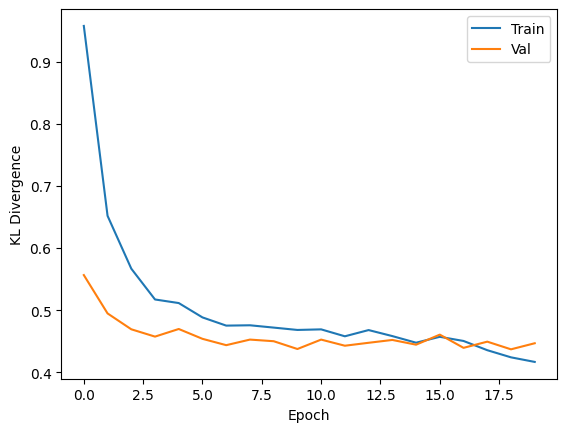

In [196]:

import math

train_losses, val_losses = [], []

best_val_loss = math.inf
EPOCHS = 20
for epoch in range(EPOCHS):
    model.train()
    running_train_loss = 0.0

    for embeddings, targets in train_loader:
        embeddings = embeddings.float()  
        optimizer.zero_grad()
        log_probs = torch.log_softmax(model(embeddings), dim=-1)
        loss = criterion(log_probs, targets)
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item() * len(targets)
    running_train_loss /= len(X_train)
    model.eval()


    running_val_loss = 0.0
    with torch.no_grad():
        for embeddings, targets in val_loader:
            embeddings = embeddings.float()
            log_probs_val = torch.log_softmax(model(embeddings), dim=-1)
            val_loss = criterion(log_probs_val, targets)
            running_val_loss += val_loss.item() * len(targets)
    
    running_val_loss /= len(X_val)

    train_losses.append(running_train_loss)
    val_losses.append(running_val_loss)

    current_lr = optimizer.param_groups[0]['lr']
    scheduler.step(running_val_loss)
    new_lr = optimizer.param_groups[0]['lr']

    if new_lr != current_lr:
        print(f"Epoch {epoch+1} | LR dropped: {current_lr:.2e} → {new_lr:.2e}")
    
    if running_val_loss < best_val_loss:
        best_val_loss = running_val_loss
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"Validation loss improved. Model saved to 'best_model.pth'")
    
 
    if epoch % 5 == 0:

      print(f"Epoch {epoch+1} | Train: {running_train_loss:.4f} | Val: {running_val_loss:.4f} | LR: {current_lr:.2e}")
    if epoch == EPOCHS - 1:
      print(f"Final Epoch {epoch+1} | Train: {running_train_loss:.4f} | Val: {running_val_loss:.4f} | LR: {current_lr:.2e}")

plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Val')
plt.xlabel('Epoch')
plt.ylabel('KL Divergence')
plt.legend()
plt.show()

In [189]:
model.eval()
running_val_loss = 0.0
all_preds = []
all_targets = []

with torch.no_grad():
    for embeddings, targets in val_loader:
        embeddings = embeddings.float()
        preds = model(embeddings)  # raw logits
        probs = torch.softmax(preds, dim=-1)           # softmax once
        
        val_loss = criterion(probs.squeeze(), targets)
        running_val_loss += val_loss.item() / len(val_loader)
        
        # Collect for JS divergence
        all_preds.append(probs.numpy())
        all_targets.append(targets.numpy())

val_losses.append(running_val_loss)
train_losses.append(running_train_loss)

# Stack all batches into one array for JS scoring
all_preds   = np.concatenate(all_preds,   axis=0)
all_targets = np.concatenate(all_targets, axis=0)

js_scores = [jensenshannon(all_targets[i], all_preds[i]) for i in range(len(all_targets))]
print(f"Mean JS divergence:   {np.mean(js_scores):.4f}")
print(f"Median JS divergence: {np.median(js_scores):.4f}")

Mean JS divergence:   0.3233
Median JS divergence: 0.3183


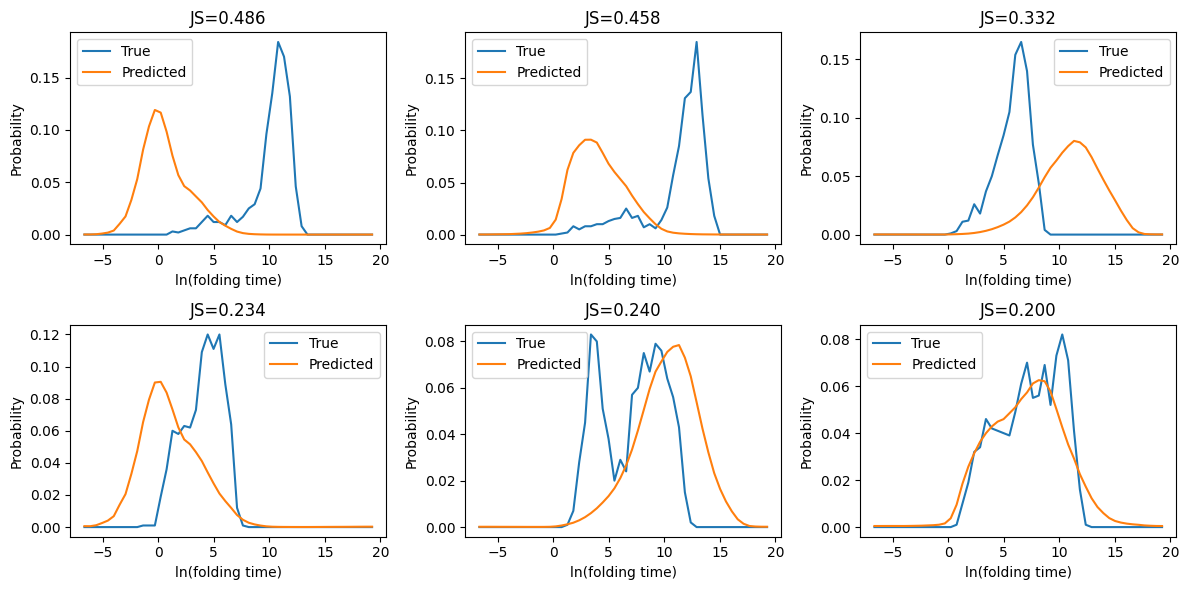

In [190]:
bin_centers = (binedges_logfpt[:-1] + binedges_logfpt[1:]) / 2

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    ax.plot(bin_centers, y_val[i], label='True')
    ax.plot(bin_centers, probs[i], label='Predicted')
    ax.set_title(f"JS={js_scores[i]:.3f}")
    ax.set_xlabel('ln(folding time)')
    ax.set_ylabel('Probability')
    ax.legend()
plt.tight_layout()
plt.show()

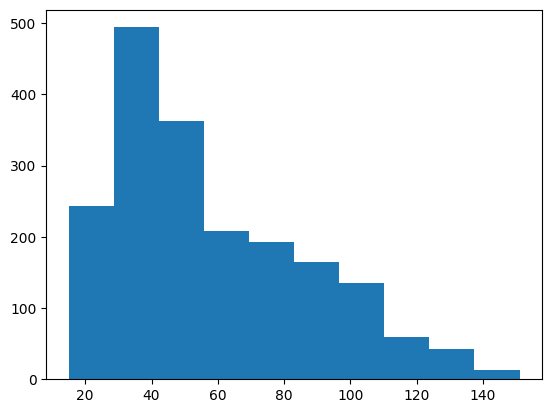

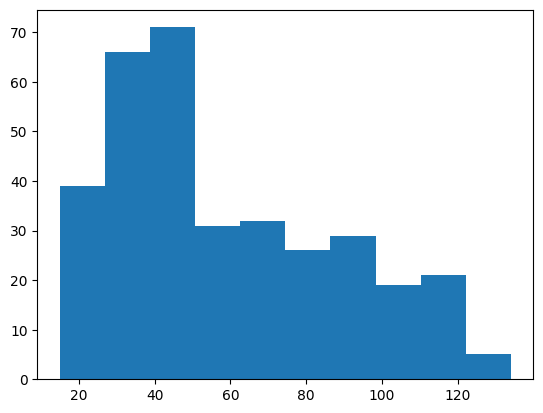

In [ ]:
plt.hist(X_train['length'])
plt.show()
plt.figure()
plt.hist(X_val['length'])
plt.show()

In [201]:
from sklearn.linear_model import Ridge
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# fit
ridge = MultiOutputRegressor(Ridge(alpha=1.0))
ridge.fit(X_train, y_train)

# predict
y_pred_val = ridge.predict(X_val)

# evaluate — KL divergence manually since sklearn doesn't have it
def kl_div(p, q):
    # p is target, q is prediction
    eps = 1e-8
    q = np.clip(q, eps, None)       # avoid log(0)
    q = q / q.sum(axis=1, keepdims=True) + eps  # renormalize predictions to sum to 1
    return np.sum(p * np.log(p / (q + eps)), axis=1).mean()

print(f"Val KL divergence: {kl_div(y_val, y_pred_val):.4f}")

Val KL divergence: nan


/var/folders/s4/rhyyvmfj319bzcp5jzhfw6qm0000gn/T/ipykernel_16364/4085264905.py:19: RuntimeWarning: divide by zero encountered in log
  return np.sum(p * np.log(p / (q + eps)), axis=1).mean()
/var/folders/s4/rhyyvmfj319bzcp5jzhfw6qm0000gn/T/ipykernel_16364/4085264905.py:19: RuntimeWarning: invalid value encountered in multiply
  return np.sum(p * np.log(p / (q + eps)), axis=1).mean()
